# Step 2: 多目的ベイズ最適化 (MOBO) + qNEHVI

Step 1 では目的関数が1つだった。ここでは **2つの目的を同時に最適化** する。

**ゴール:**
- パレートフロント（トレードオフの最前線）の概念を理解
- qNEHVI 獲得関数でパレートフロントを効率的に探索
- BraninCurrin テスト関数で実践

**Step 1 → Step 2 の変更点:**

| | Step 1 (単目的) | Step 2 (多目的) |
|---|---|---|
| **目的関数** | f(x) → 1つのスカラー | f(x) → 2つのスカラー |
| **獲得関数** | EI（改善の期待値） | qNEHVI（パレート超体積改善の期待値） |
| **最適解** | 1点 | パレートフロント（解の集合） |

**構成:**
1. パレートフロントとは何か
2. BraninCurrin テスト関数
3. MOBO ループの実装
4. パレートフロントの成長を可視化

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.multi_objective.logei import qLogNoisyExpectedHypervolumeImprovement
from botorch.optim import optimize_acqf
from botorch.test_functions.multi_objective import BraninCurrin
from botorch.utils.multi_objective.pareto import is_non_dominated
from botorch.utils.multi_objective.hypervolume import Hypervolume
from botorch.utils.sampling import draw_sobol_samples
from gpytorch.mlls import ExactMarginalLogLikelihood

# BoTorch は double precision 推奨
dtype = torch.double
torch.manual_seed(42)
%matplotlib inline

## 1. パレートフロントとは

論文の文脈: ポリマーの「熱伝導率（高いほど良い）」と「柔軟性（低弾性率 = 高いほど良い）」を同時に最適化したい。

- 熱伝導率を上げると硬くなりがち → **トレードオフ**
- 「どの目的でも他の解に劣らない解の集合」= **パレートフロント**
- パレートフロント上の解はどれも最適。どれを選ぶかは意思決定者（研究者）が決める

qNEHVI = 「この候補を評価したら、パレートフロントが囲む **超体積（Hypervolume）** がどれだけ増えるか」の期待値。
超体積が大きいほど、パレートフロントが広く・遠くまで広がっている = 良い解の集合。

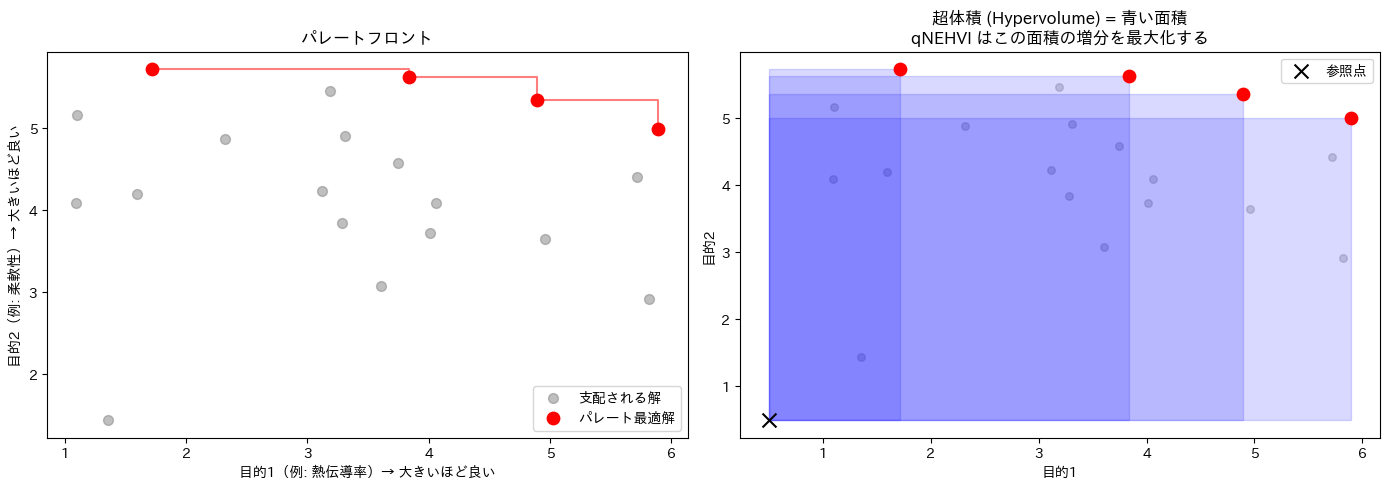

In [2]:
# パレートフロントと超体積の概念図
np.random.seed(0)
points = np.random.rand(20, 2) * 5 + np.array([1, 1])

# パレート支配の判定（最大化）
Y_torch = torch.tensor(points)
pareto_mask = is_non_dominated(Y_torch).numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左: パレートフロントの説明
ax1.scatter(points[~pareto_mask, 0], points[~pareto_mask, 1],
            c="gray", alpha=0.5, s=50, label="支配される解")
ax1.scatter(points[pareto_mask, 0], points[pareto_mask, 1],
            c="red", s=80, zorder=5, label="パレート最適解")

# パレートフロントを線で結ぶ
pareto_pts = points[pareto_mask]
pareto_pts = pareto_pts[pareto_pts[:, 0].argsort()]
ax1.step(pareto_pts[:, 0], pareto_pts[:, 1], "r-", where="post", alpha=0.5)

ax1.set_xlabel("目的1（例: 熱伝導率）→ 大きいほど良い")
ax1.set_ylabel("目的2（例: 柔軟性）→ 大きいほど良い")
ax1.set_title("パレートフロント")
ax1.legend()

# 右: 超体積の説明
ref_point = np.array([0.5, 0.5])
ax2.scatter(points[~pareto_mask, 0], points[~pareto_mask, 1],
            c="gray", alpha=0.3, s=30)
ax2.scatter(points[pareto_mask, 0], points[pareto_mask, 1],
            c="red", s=80, zorder=5)

# 超体積を塗りつぶし
for i, pt in enumerate(pareto_pts):
    if i < len(pareto_pts) - 1:
        next_pt = pareto_pts[i + 1]
        rect_x = [pt[0], next_pt[0], next_pt[0], pt[0]]
        rect_y = [ref_point[1], ref_point[1], pt[1], pt[1]]
    else:
        rect_x = [pt[0], pt[0], pt[0], pt[0]]
        rect_y = [ref_point[1], ref_point[1], pt[1], pt[1]]
    ax2.fill([ref_point[0], pt[0], pt[0], ref_point[0]],
             [ref_point[1], ref_point[1], pt[1], pt[1]],
             alpha=0.15, color="blue")

ax2.scatter(*ref_point, c="black", marker="x", s=100, zorder=5, label="参照点")
ax2.set_xlabel("目的1")
ax2.set_ylabel("目的2")
ax2.set_title("超体積 (Hypervolume) = 青い面積\nqNEHVI はこの面積の増分を最大化する")
ax2.legend()

plt.tight_layout()
plt.show()

## 2. BraninCurrin テスト関数

2入力 → 2出力 の多目的テスト関数。MOBO のベンチマークに使われる。

- **目的1**: Branin 関数（negated）
- **目的2**: Currin 関数（negated）
- 入力: (x1, x2) ∈ [0, 1]²
- `negate=True` で最大化問題に変換（BoTorch の慣習）

BraninCurrin:
  入力次元: 2
  目的数:   2
  探索範囲: [[0.0, 0.0], [1.0, 1.0]]


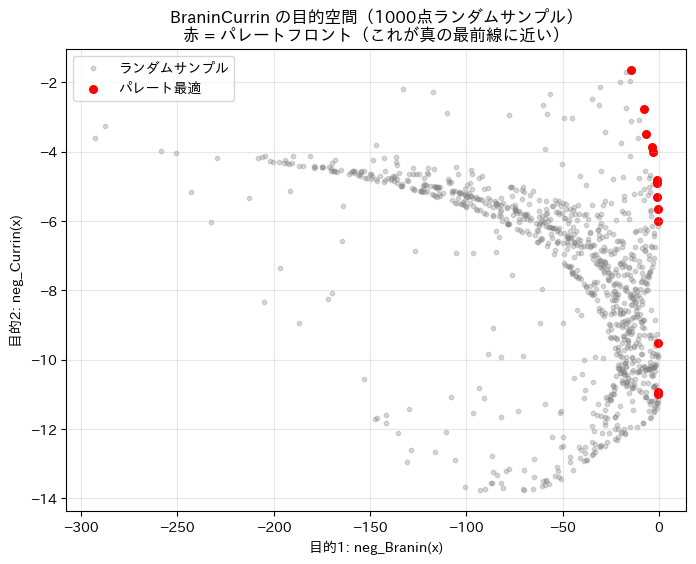


→ 目的1と目的2はトレードオフ関係。MOBO はこのパレートフロントを少ない評価で見つける。


In [4]:
problem = BraninCurrin(negate=True)
bounds = problem.bounds.to(dtype=dtype)

print(f"BraninCurrin:")
print(f"  入力次元: {problem.dim}")
print(f"  目的数:   {problem.num_objectives}")
print(f"  探索範囲: {bounds.tolist()}")

# 目的空間を可視化: ランダムに1000点サンプルして2目的の分布を見る
X_random = torch.rand(1000, 2, dtype=dtype)
Y_random = problem(X_random)

pareto_mask_all = is_non_dominated(Y_random)

plt.figure(figsize=(8, 6))
plt.scatter(Y_random[~pareto_mask_all, 0], Y_random[~pareto_mask_all, 1],
            c="gray", alpha=0.3, s=10, label="ランダムサンプル")
plt.scatter(Y_random[pareto_mask_all, 0], Y_random[pareto_mask_all, 1],
            c="red", s=30, label="パレート最適")
plt.xlabel("目的1: neg_Branin(x)")
plt.ylabel("目的2: neg_Currin(x)")
plt.title("BraninCurrin の目的空間（1000点ランダムサンプル）\n赤 = パレートフロント（これが真の最前線に近い）")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\n→ 目的1と目的2はトレードオフ関係。MOBO はこのパレートフロントを少ない評価で見つける。")

## 3. MOBO ループの実装

Step 1 との違い:
- GP が **2出力** を同時にモデリング（`SingleTaskGP` は multi-output 対応）
- 獲得関数が `EI` → `qLogNoisyExpectedHypervolumeImprovement`（qLogNEHVI）
  - BoTorch 0.17 では Log 版が推奨（数値安定性が向上）
- **参照点 (reference point)** を設定する必要がある（超体積の原点）

In [5]:
# 参照点: 超体積計算の原点。全目的でこれより悪い解は無視される。
# BraninCurrin は negate=True なので、negated 後の参照点を設定
ref_point = torch.tensor([-18.0, -6.0], dtype=dtype)
hv = Hypervolume(ref_point=ref_point)

print(f"参照点: {ref_point.tolist()}")
print("  → 超体積はこの点を原点として、パレートフロントが囲む面積を計算")
print("  → qNEHVI は「次の1点でこの面積をどれだけ増やせるか」を最大化")

参照点: [-18.0, -6.0]
  → 超体積はこの点を原点として、パレートフロントが囲む面積を計算
  → qNEHVI は「次の1点でこの面積をどれだけ増やせるか」を最大化


In [6]:
def run_mobo(problem, bounds, ref_point, n_initial=10, n_iterations=30, seed=0):
    """多目的ベイズ最適化ループ"""
    torch.manual_seed(seed)

    # 初期データ: Sobol 列でバランスよくサンプリング
    train_X = draw_sobol_samples(bounds=bounds, n=n_initial, q=1, seed=seed).squeeze(1)
    train_Y = problem(train_X)

    hv = Hypervolume(ref_point=ref_point)
    history = []

    # 初期パレートフロントの超体積
    pareto_mask = is_non_dominated(train_Y)
    initial_hv = hv.compute(train_Y[pareto_mask])
    history.append({
        "iteration": 0,
        "hv": initial_hv,
        "n_pareto": pareto_mask.sum().item(),
        "train_Y": train_Y.clone(),
    })
    print(f"  初期: {n_initial}点, パレート最適={pareto_mask.sum().item()}点, HV={initial_hv:.4f}")

    for i in range(n_iterations):
        # 1. GP フィット（2出力を同時にモデリング）
        model = SingleTaskGP(train_X, train_Y)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)

        # 2. qLogNEHVI 獲得関数
        acqf = qLogNoisyExpectedHypervolumeImprovement(
            model=model,
            ref_point=ref_point.tolist(),
            X_baseline=train_X,
        )

        # 3. 獲得関数を最適化して次の候補を選択
        candidate, _ = optimize_acqf(
            acq_function=acqf,
            bounds=bounds,
            q=1,
            num_restarts=8,
            raw_samples=64,
        )

        # 4. 評価 & データ更新
        new_Y = problem(candidate)
        train_X = torch.cat([train_X, candidate])
        train_Y = torch.cat([train_Y, new_Y])

        # 超体積を記録
        pareto_mask = is_non_dominated(train_Y)
        current_hv = hv.compute(train_Y[pareto_mask])
        history.append({
            "iteration": i + 1,
            "hv": current_hv,
            "n_pareto": pareto_mask.sum().item(),
            "train_Y": train_Y.clone(),
        })

        if (i + 1) % 5 == 0:
            print(f"  iter {i+1:2d}: パレート最適={pareto_mask.sum().item()}点, HV={current_hv:.4f}")

    return train_X, train_Y, history

print("MOBO ループ開始 (30 iterations):")
train_X_mo, train_Y_mo, history_mo = run_mobo(problem, bounds, ref_point)

pareto_final = is_non_dominated(train_Y_mo)
print(f"\n最終結果:")
print(f"  合計評価: {len(train_X_mo)} 点 (初期10 + MOBO 30)")
print(f"  パレート最適: {pareto_final.sum().item()} 点")
print(f"  超体積: {history_mo[-1]['hv']:.4f}")

MOBO ループ開始 (30 iterations):
  初期: 10点, パレート最適=5点, HV=0.0000
  iter  5: パレート最適=4点, HV=43.6381
  iter 10: パレート最適=8点, HV=52.7816


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[NumericalWarning('A not p.d., added jitter of 1.0e-08 to the diagonal'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[NumericalWarning('A not p.d., added jitter of 1.0e-08 to the diagonal'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: 

  iter 15: パレート最適=12点, HV=54.8566


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[NumericalWarning('A not p.d., added jitter of 1.0e-08 to the diagonal'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and m

  iter 20: パレート最適=16点, HV=56.6566


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.

  iter 25: パレート最適=21点, HV=57.1255


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the d

  iter 30: パレート最適=24点, HV=57.2956

最終結果:
  合計評価: 40 点 (初期10 + MOBO 30)
  パレート最適: 24 点
  超体積: 57.2956


## 4. パレートフロントの成長を可視化

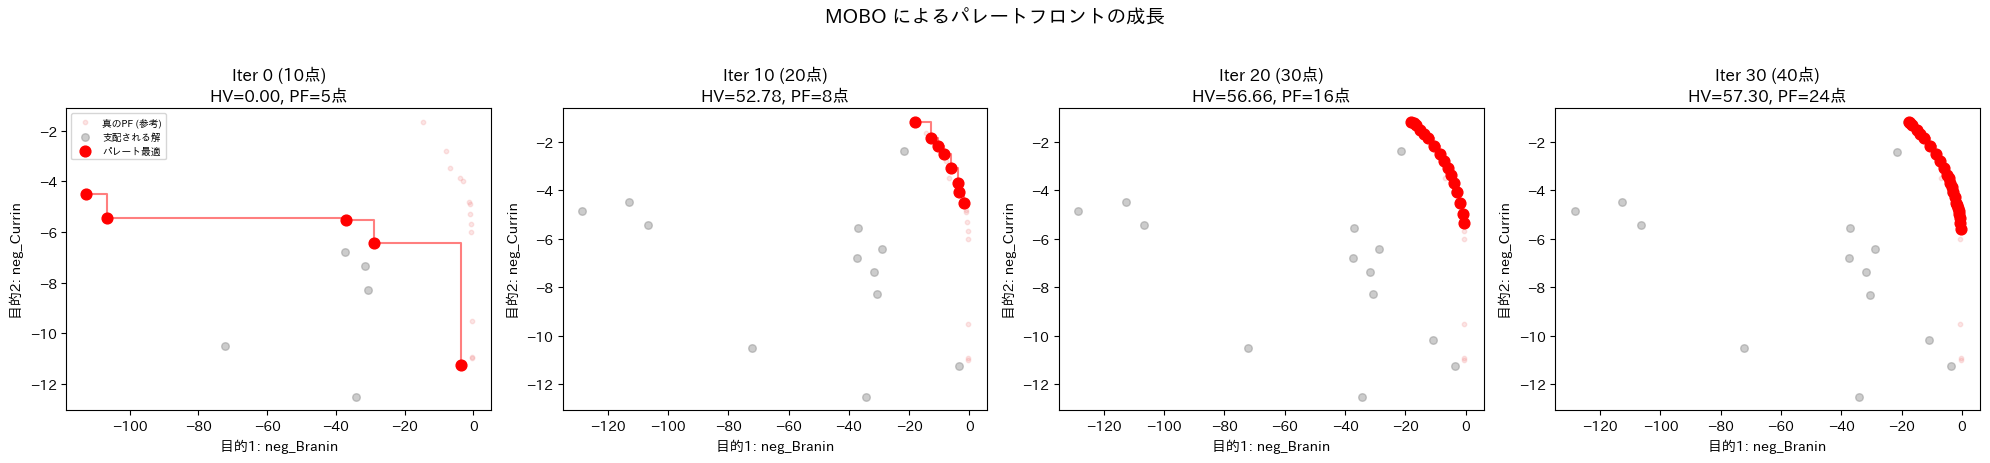

In [7]:
# パレートフロントの成長: 初期 → 中間 → 最終
snapshots = [0, 10, 20, 30]  # iteration 0, 10, 20, 30

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, snap_iter in zip(axes, snapshots):
    h = history_mo[snap_iter]
    Y = h["train_Y"]
    pareto_mask = is_non_dominated(Y)

    # ランダムサンプルの真のパレートフロント（参考用）
    ax.scatter(Y_random[pareto_mask_all, 0], Y_random[pareto_mask_all, 1],
               c="lightcoral", alpha=0.2, s=10, label="真のPF (参考)")

    ax.scatter(Y[~pareto_mask, 0], Y[~pareto_mask, 1],
               c="gray", alpha=0.4, s=30, label="支配される解")
    ax.scatter(Y[pareto_mask, 0], Y[pareto_mask, 1],
               c="red", s=60, zorder=5, label="パレート最適")

    # パレートフロントを線で結ぶ
    pf = Y[pareto_mask].numpy()
    pf = pf[pf[:, 0].argsort()]
    ax.step(pf[:, 0], pf[:, 1], "r-", where="post", alpha=0.5)

    ax.set_xlabel("目的1: neg_Branin")
    ax.set_ylabel("目的2: neg_Currin")
    ax.set_title(f"Iter {snap_iter} ({len(Y)}点)\nHV={h['hv']:.2f}, PF={h['n_pareto']}点")
    if snap_iter == 0:
        ax.legend(fontsize=7)

plt.suptitle("MOBO によるパレートフロントの成長", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

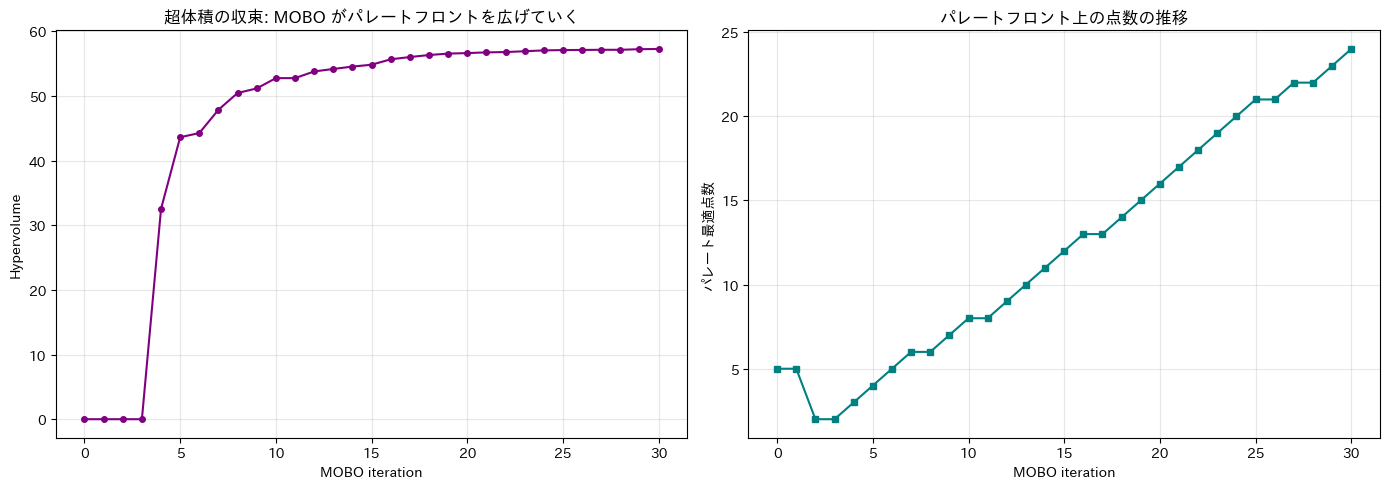

In [8]:
# 超体積の収束プロット
hvs = [h["hv"] for h in history_mo]
iters = [h["iteration"] for h in history_mo]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左: 超体積の推移
ax1.plot(iters, hvs, "o-", color="purple", markersize=4)
ax1.set_xlabel("MOBO iteration")
ax1.set_ylabel("Hypervolume")
ax1.set_title("超体積の収束: MOBO がパレートフロントを広げていく")
ax1.grid(alpha=0.3)

# 右: パレート最適点数の推移
n_paretos = [h["n_pareto"] for h in history_mo]
ax2.plot(iters, n_paretos, "s-", color="teal", markersize=4)
ax2.set_xlabel("MOBO iteration")
ax2.set_ylabel("パレート最適点数")
ax2.set_title("パレートフロント上の点数の推移")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

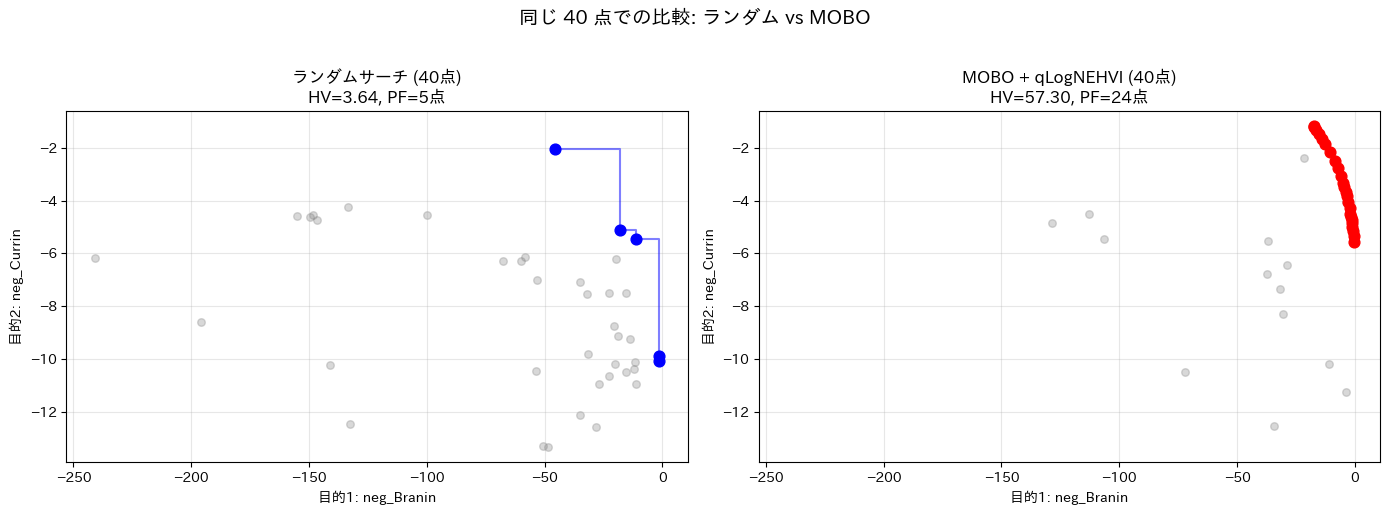

超体積の比較:
  ランダム: 3.64
  MOBO:     57.30
  → MOBO は同じ評価回数で 15.7x 広いパレートフロントを発見


In [9]:
# ランダムサーチとの比較: 同じ評価回数でランダムに選んだ場合
torch.manual_seed(42)
n_total = len(train_X_mo)
X_rand_compare = torch.rand(n_total, 2, dtype=dtype)
Y_rand_compare = problem(X_rand_compare)

pareto_rand = is_non_dominated(Y_rand_compare)
hv_rand = hv.compute(Y_rand_compare[pareto_rand])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左: ランダムサーチ
ax1.scatter(Y_rand_compare[~pareto_rand, 0], Y_rand_compare[~pareto_rand, 1],
            c="gray", alpha=0.3, s=30)
ax1.scatter(Y_rand_compare[pareto_rand, 0], Y_rand_compare[pareto_rand, 1],
            c="blue", s=60, zorder=5)
pf_rand = Y_rand_compare[pareto_rand].numpy()
pf_rand = pf_rand[pf_rand[:, 0].argsort()]
ax1.step(pf_rand[:, 0], pf_rand[:, 1], "b-", where="post", alpha=0.5)
ax1.set_xlabel("目的1: neg_Branin")
ax1.set_ylabel("目的2: neg_Currin")
ax1.set_title(f"ランダムサーチ ({n_total}点)\nHV={hv_rand:.2f}, PF={pareto_rand.sum().item()}点")

# 右: MOBO
pareto_mo = is_non_dominated(train_Y_mo)
ax2.scatter(train_Y_mo[~pareto_mo, 0], train_Y_mo[~pareto_mo, 1],
            c="gray", alpha=0.3, s=30)
ax2.scatter(train_Y_mo[pareto_mo, 0], train_Y_mo[pareto_mo, 1],
            c="red", s=60, zorder=5)
pf_mo = train_Y_mo[pareto_mo].numpy()
pf_mo = pf_mo[pf_mo[:, 0].argsort()]
ax2.step(pf_mo[:, 0], pf_mo[:, 1], "r-", where="post", alpha=0.5)
ax2.set_xlabel("目的1: neg_Branin")
ax2.set_ylabel("目的2: neg_Currin")
ax2.set_title(f"MOBO + qLogNEHVI ({n_total}点)\nHV={history_mo[-1]['hv']:.2f}, PF={pareto_mo.sum().item()}点")

# 軸範囲を揃える
for ax in [ax1, ax2]:
    ax.set_xlim(ax1.get_xlim()[0], max(ax1.get_xlim()[1], ax2.get_xlim()[1]))
    ax.set_ylim(ax1.get_ylim()[0], max(ax1.get_ylim()[1], ax2.get_ylim()[1]))
    ax.grid(alpha=0.3)

plt.suptitle(f"同じ {n_total} 点での比較: ランダム vs MOBO", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print(f"超体積の比較:")
print(f"  ランダム: {hv_rand:.2f}")
print(f"  MOBO:     {history_mo[-1]['hv']:.2f}")
print(f"  → MOBO は同じ評価回数で {history_mo[-1]['hv'] / hv_rand:.1f}x 広いパレートフロントを発見")

## まとめ

### Step 1 → Step 2 で学んだこと

| コンポーネント | Step 1 (単目的) | Step 2 (MOBO) |
|---|---|---|
| **サロゲートモデル** | `SingleTaskGP` (1出力) | `SingleTaskGP` (2出力) |
| **獲得関数** | `ExpectedImprovement` | `qLogNoisyExpectedHypervolumeImprovement` |
| **評価指標** | best f(x) | Hypervolume（パレートフロントの面積） |
| **参照点** | best_f | ref_point（超体積の原点） |

### 論文との対応

| この notebook | 論文 |
|---|---|
| 目的1 (neg_Branin) | 熱伝導率 (TC) |
| 目的2 (neg_Currin) | 柔軟性 (1/Bulk Modulus) |
| qLogNEHVI | qNEHVI（論文では Log 版の前のバージョン） |
| SingleTaskGP | DKL サロゲート（→ Step 3 で置き換え） |

### Step 3 への接続

- `SingleTaskGP`（標準的な GP）→ **DKL**（NN + GP のハイブリッド）に置き換え
- 高次元の分子記述子を扱うには GP だけでは不十分 → NN で特徴抽出してから GP に渡す